# Análisis exploratorio del dataset MIMIC-IV-ED

Este notebook realiza la exploración inicial de las tablas que componen MIMIC-IV-ED. El objetivo es doble: por un lado, caracterizar la población y las variables disponibles para justificar las decisiones de diseño del pipeline de modelado; por otro, generar los artefactos intermedios (`data/interim/`) que el resto del pipeline necesita.

**Este notebook debe ejecutarse una vez antes de usar `loader.py`.** Genera:
- `data/interim/ccs_icd9_clean.parquet`
- `data/interim/ccs_icd10_clean.parquet`
- `data/interim/label_map_ccs.parquet`

## 1. Carga de tablas raw

Se cargan las seis tablas principales de MIMIC-IV-ED directamente desde los ficheros comprimidos. Para cada tabla se inspeccionan los tipos de columna, el porcentaje de valores nulos y las primeras filas, lo que permite detectar problemas de formato y entender la granularidad de cada tabla antes de cualquier transformación.

In [2]:
import pandas as pd
from pathlib import Path

BASE = Path("..") / "data" / "raw"
tablas = ["edstays", "triage", "vitalsign", 
          "diagnosis", "medrecon", "pyxis"]

dfs = {}
for tabla in tablas:
    dfs[tabla] = pd.read_csv(BASE / f"{tabla}.csv.gz", low_memory=False)
    print(f"\n{'='*50}")
    print(f"{tabla.upper()}: {dfs[tabla].shape}")
    print(dfs[tabla].dtypes)
    print(dfs[tabla].isnull().mean().sort_values(ascending=False).head(10))
    print(dfs[tabla].head(3))


EDSTAYS: (425087, 9)
subject_id             int64
hadm_id              float64
stay_id                int64
intime                object
outtime               object
gender                object
race                  object
arrival_transport     object
disposition           object
dtype: object
hadm_id              0.522413
subject_id           0.000000
stay_id              0.000000
intime               0.000000
outtime              0.000000
gender               0.000000
race                 0.000000
arrival_transport    0.000000
disposition          0.000000
dtype: float64
   subject_id     hadm_id   stay_id               intime              outtime  \
0    10000032  22595853.0  33258284  2180-05-06 19:17:00  2180-05-06 23:30:00   
1    10000032  22841357.0  38112554  2180-06-26 15:54:00  2180-06-26 21:31:00   
2    10000032  25742920.0  35968195  2180-08-05 20:58:00  2180-08-06 01:44:00   

  gender   race arrival_transport disposition  
0      F  WHITE         AMBULANCE    ADMITTED

## 2. Primer vistazo a las variables clave

Inspección rápida de las distribuciones más relevantes para orientar el análisis posterior:
- **Acuity**: el nivel de triaje asignado por el enfermero (1=crítico, 5=no urgente), que constituye uno de los dos targets del modelo.
- **ICD version**: proporción de diagnósticos codificados en ICD-9 vs. ICD-10, que motiva la necesidad de unificación mediante CCS.
- **Clases farmacológicas**: las 20 categorías de medicación previa más frecuentes en `medrecon`, que orientan la selección de flags binarios.

In [3]:
print("=== ACUITY ===")
print(dfs["triage"]["acuity"].value_counts().sort_index())

print("\n=== ICD VERSION ===")
print(dfs["diagnosis"]["icd_version"].value_counts())

print("\n=== CLASES FARMACOLÓGICAS TOP 20 ===")
print(dfs["medrecon"]["etcdescription"].value_counts().head(20))

=== ACUITY ===
acuity
1.0     24019
2.0    139411
3.0    225066
4.0     28504
5.0      1100
Name: count, dtype: int64

=== ICD VERSION ===
icd_version
10    456035
9     443015
Name: count, dtype: int64

=== CLASES FARMACOLÓGICAS TOP 20 ===
etcdescription
Antihyperlipidemic - HMG CoA Reductase Inhibitors (statins)               102285
Gastric Acid Secretion Reducing Agents - Proton Pump Inhibitors (PPIs)     93308
Salicylate Analgesics                                                      87881
Platelet Aggregation Inhibitors - Salicylates                              87178
Vitamins - D Derivatives                                                   69988
Beta Blockers Cardiac Selective                                            68528
Benzodiazepines                                                            63188
Antianxiety Agent - Benzodiazepines                                        61048
Analgesic Opioid Agonists                                                  60904
Antidepressant 

## 3. Configuración del estilo gráfico

Se establece una paleta y un estilo visual uniforme para todas las figuras del notebook

In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import numpy as np

# Paleta y estilo base
AZUL_PRINCIPAL = "#2C3E7A"
AZUL_CLARO     = "#5B7FC4"
GRIS_TEXTO     = "#2B2B2B"
GRIS_FONDO     = "#F7F7F7"
GRIS_BORDE     = "#CCCCCC"

PALETA_ACUITY = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]
PALETA_GENERAL = sns.color_palette("Blues_d", 10)

mpl.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Georgia", "Times New Roman"],
    "font.size":          11,
    "axes.titlesize":     13,
    "axes.labelsize":     11,
    "axes.titleweight":   "bold",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "axes.grid.axis":     "x",
    "grid.color":         GRIS_BORDE,
    "grid.linewidth":     0.5,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "legend.fontsize":    9,
    "legend.frameon":     False,
    "figure.facecolor":   "white",
    "axes.facecolor":     GRIS_FONDO,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})

print("Estilo academico configurado.")

Estilo academico configurado.


## 4. Distribución del nivel de triaje (Acuity)

La variable `acuity` es el target principal del modelo de clasificación multiclase. Se analiza su distribución para cuantificar el desbalance entre clases (factor crítico para el entranenamiento)

El marcado predominio del Nivel 3 (urgente, ~53%) frente a los niveles extremos refleja la distribución real de una urgencia hospitalaria: los casos críticos son minoritarios pero clínicamente prioritarios.

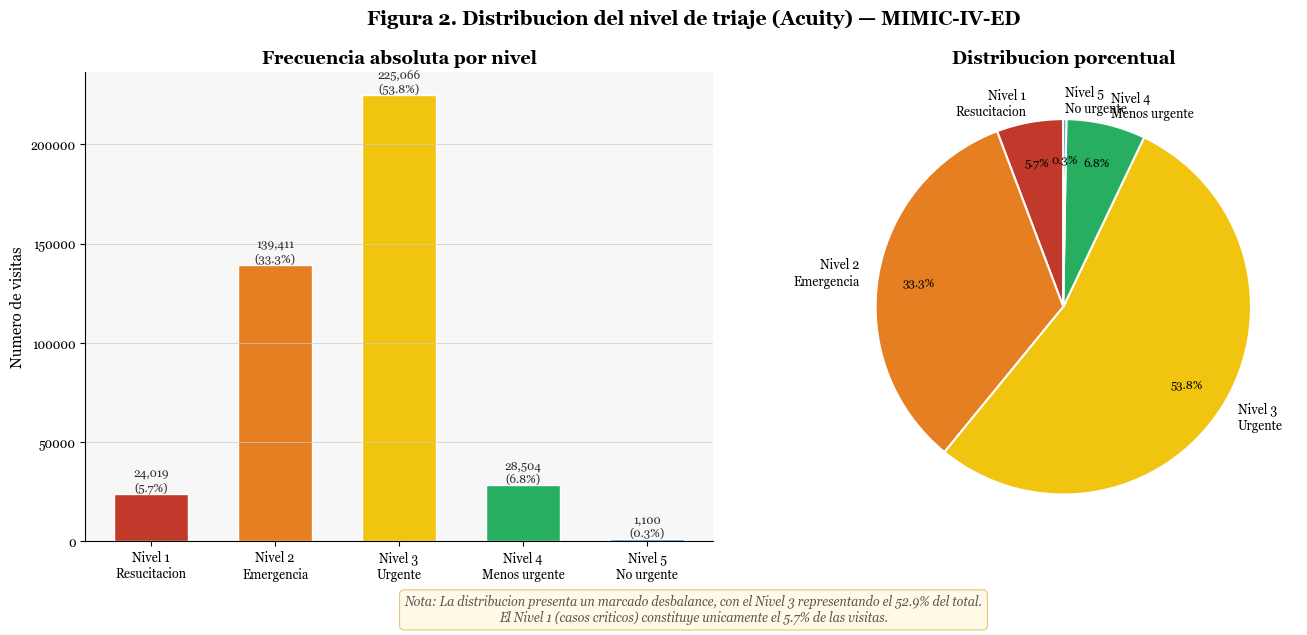

In [5]:

acuity = dfs["triage"]["acuity"].value_counts().sort_index()
etiquetas = ["Nivel 1\nResucitacion", "Nivel 2\nEmergencia",
             "Nivel 3\nUrgente", "Nivel 4\nMenos urgente",
             "Nivel 5\nNo urgente"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "Figura 2. Distribucion del nivel de triaje (Acuity) — MIMIC-IV-ED",
    fontsize=14, fontweight="bold"
)

# Barplot
bars = axes[0].bar(etiquetas, acuity.values,
                   color=PALETA_ACUITY, edgecolor="white", width=0.6)
axes[0].set_ylabel("Numero de visitas")
axes[0].set_title("Frecuencia absoluta por nivel")
axes[0].grid(axis="y", linewidth=0.5)
axes[0].grid(axis="x", visible=False)
for bar, val in zip(bars, acuity.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1000,
                 f"{val:,}\n({val/acuity.sum()*100:.1f}%)",
                 ha="center", fontsize=8.5, color=GRIS_TEXTO)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    acuity.values,
    labels=etiquetas,
    colors=PALETA_ACUITY,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    pctdistance=0.78,
)
for t in autotexts:
    t.set_fontsize(8.5)
axes[1].set_title("Distribucion porcentual")

note = (
    "Nota: La distribucion presenta un marcado desbalance, "
    "con el Nivel 3 representando el 52.9% del total.\n"
    "El Nivel 1 (casos criticos) constituye unicamente el 5.7% de las visitas."
)
fig.text(0.5, -0.04, note, ha="center", fontsize=9,
         color="#555555", style="italic",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#FFF9E6",
                   edgecolor="#E0C97A", linewidth=0.8))

plt.tight_layout()
plt.show()

## 5. Distribución de constantes vitales por nivel de triaje

Las constantes vitales recogidas en el momento del triaje (frecuencia cardíaca, respiratoria, saturación de oxígeno, presión arterial y temperatura) son las features facilmente disponibles en el minuto 0. Se analiza su distribución estratificada por nivel de acuity para verificar que existe separabilidad entre clases, lo que justifica su inclusión como predictores.



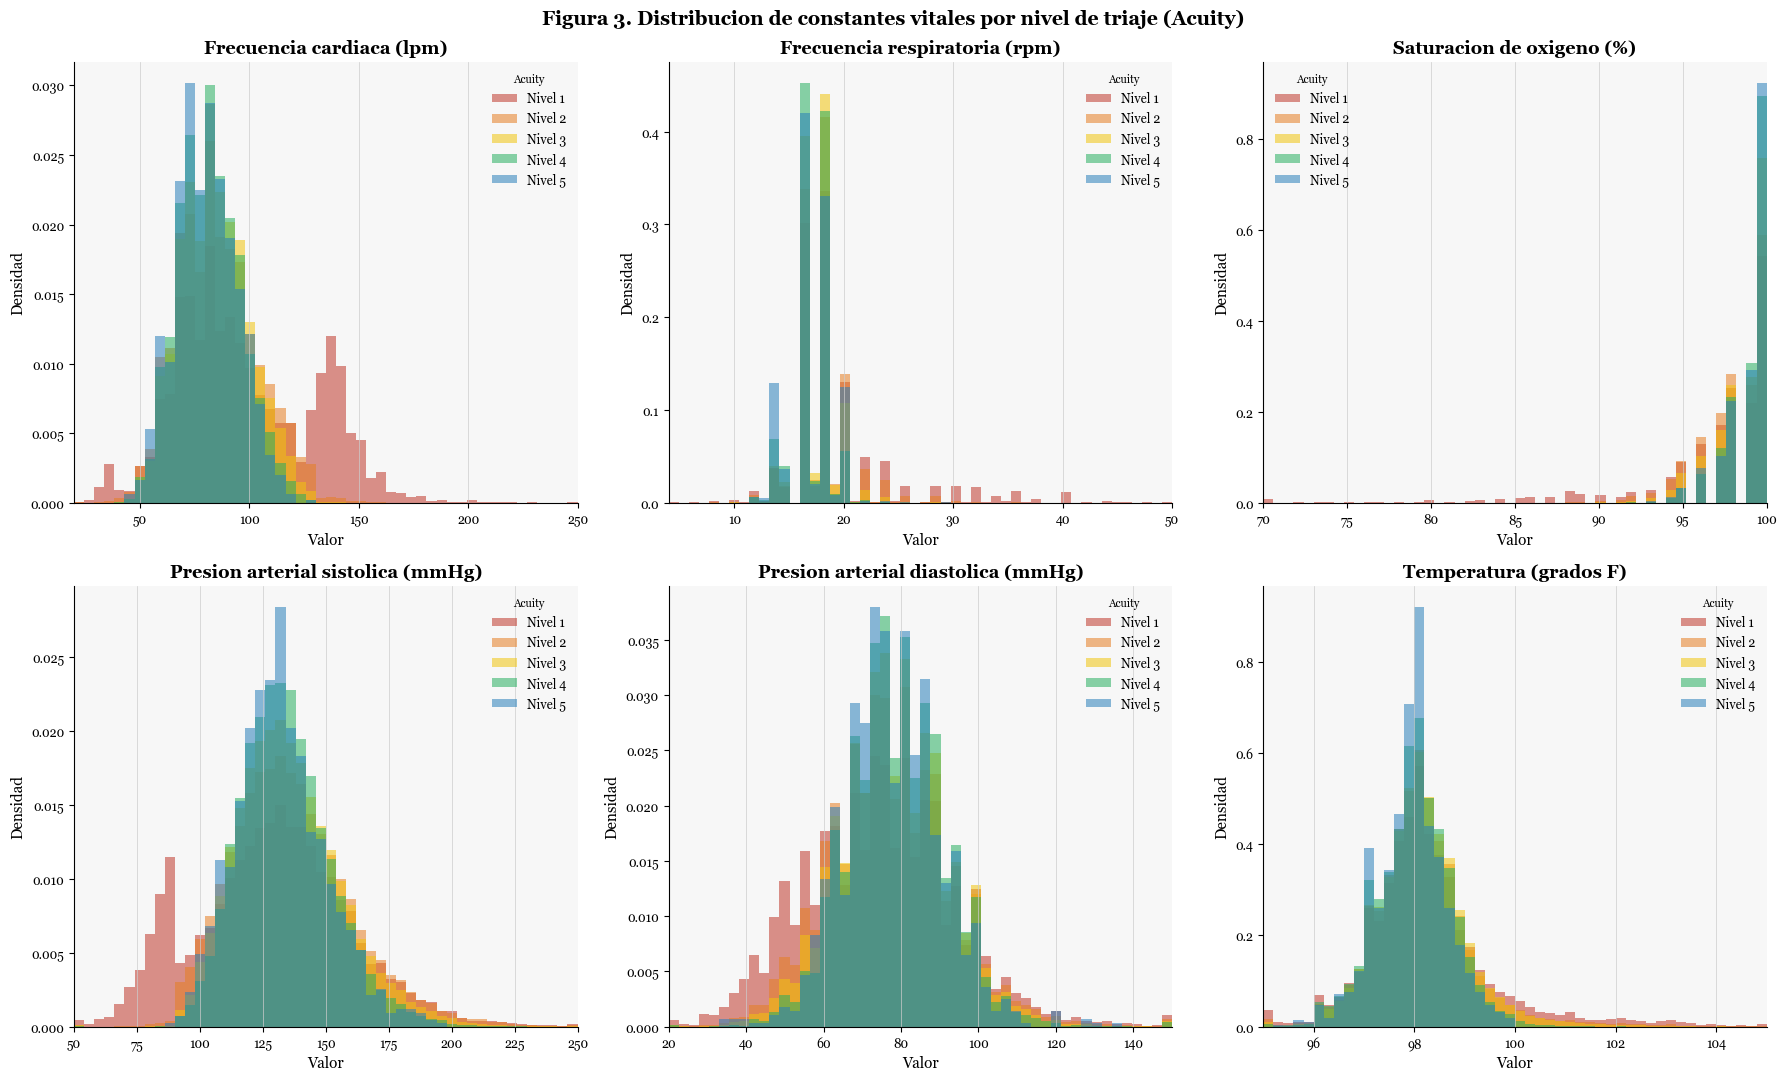

Tabla 1. Mediana de constantes vitales por nivel de triaje

         Frecuencia cardiaca (lpm)  Frecuencia respiratoria (rpm)  Saturacion de oxigeno (%)  Presion arterial sistolica (mmHg)  Presion arterial diastolica (mmHg)  Temperatura (grados F)
Nivel 1                       92.0                           18.0                       98.0                              129.0                                74.0                    98.0
Nivel 2                       84.0                           18.0                       99.0                              133.0                                77.0                    98.0
Nivel 3                       83.0                           18.0                       99.0                              133.0                                78.0                    98.0
Nivel 4                       81.0                           16.0                      100.0                              132.0                                78.0                    98.0


In [ ]:
vitales = {
    "heartrate":   ("Frecuencia cardiaca (lpm)",          20,  250),
    "resprate":    ("Frecuencia respiratoria (rpm)",        4,   50),
    "o2sat":       ("Saturacion de oxigeno (%)",           70,  100),
    "sbp":         ("Presion arterial sistolica (mmHg)",   50,  250),
    "dbp":         ("Presion arterial diastolica (mmHg)",  20,  150),
    "temperature": ("Temperatura (grados F)",              95,  105),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    "Figura 3. Distribucion de constantes vitales por nivel de triaje (Acuity)",
    fontsize=14, fontweight="bold"
)

for ax, (col, (titulo, vmin, vmax)) in zip(axes.flatten(), vitales.items()):
    for nivel, color in zip([1, 2, 3, 4, 5], PALETA_ACUITY):
        datos = (
            dfs["triage"][dfs["triage"]["acuity"] == nivel][col]
            .dropna()
            .clip(vmin, vmax)   # <- recorte al rango clínico
        )
        ax.hist(datos, bins=50, alpha=0.55, range=(vmin, vmax),
                label=f"Nivel {int(nivel)}", color=color, density=True)

    ax.set_title(titulo, pad=6)
    ax.set_xlabel("Valor")
    ax.set_ylabel("Densidad")
    ax.set_xlim(vmin, vmax)
    ax.legend(title="Acuity", title_fontsize=8)

plt.tight_layout()
plt.show()

# Tabla resumen
print("Tabla 1. Mediana de constantes vitales por nivel de triaje\n")
resumen_vitales = (
    dfs["triage"]
    .groupby("acuity")[[col for col in vitales]]
    .median()
    .round(1)
)
resumen_vitales.index   = [f"Nivel {int(i)}" for i in resumen_vitales.index]
resumen_vitales.columns = [v[0] for v in vitales.values()]
print(resumen_vitales.to_string())

## 6. Medio de llegada, destino y medicación previa

Se exploran tres variables con implicaciones distintas en el modelo:

- **Arrival transport**: el medio por el que el paciente llega a urgencias (ambulancia, a pie, helicóptero...). Es una señal de gravedad percibida antes del triaje formal.
- **Disposition**: el destino al alta (ingreso, alta a domicilio, traslado...). Constituye el segundo target del modelo, que se binarizará en `label_disposition`.
- **Medicación previa (medrecon)**: las clases farmacológicas más frecuentes en el historial de medicación en casa. Permiten inferir comorbilidades crónicas del paciente sin necesidad de acceder al diagnóstico.

C:\Users\CARLOS\AppData\Local\Temp\ipykernel_28384\2688852849.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_yticklabels(short_labels, fontsize=8)


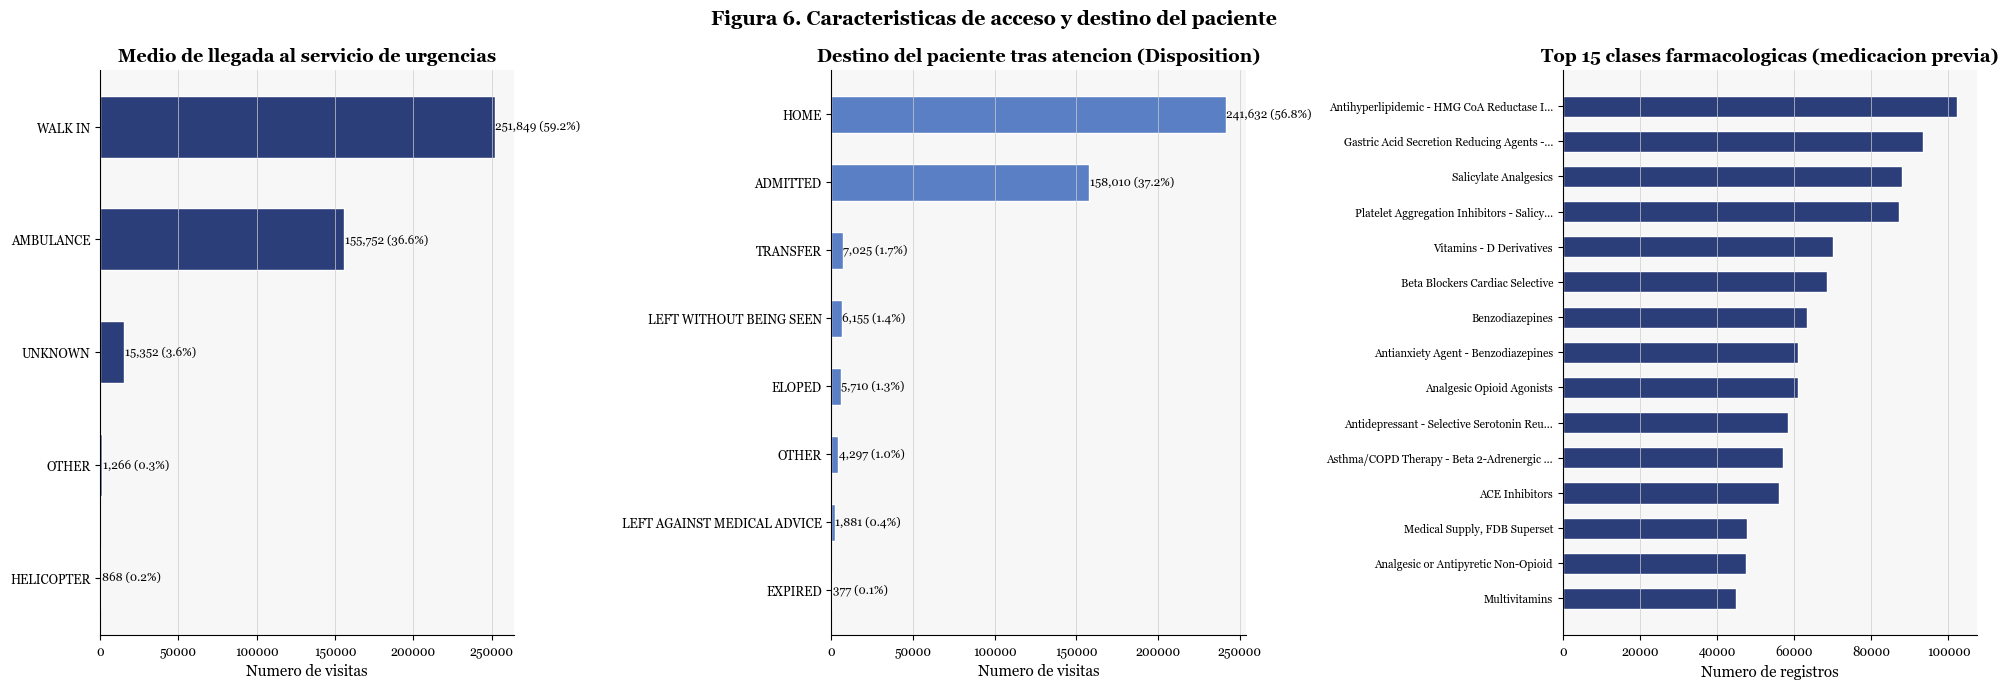

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(
    "Figura 6. Caracteristicas de acceso y destino del paciente",
    fontsize=14, fontweight="bold"
)

# Arrival transport
transport = dfs["edstays"]["arrival_transport"].value_counts()
axes[0].barh(transport.index, transport.values,
             color=AZUL_PRINCIPAL, edgecolor="white", height=0.55)
axes[0].set_title("Medio de llegada al servicio de urgencias")
axes[0].set_xlabel("Numero de visitas")
axes[0].invert_yaxis()
axes[0].grid(axis="y", visible=False)
for i, val in enumerate(transport.values):
    axes[0].text(val + 300, i,
                 f"{val:,} ({val/transport.sum()*100:.1f}%)",
                 va="center", fontsize=8.5)

# Disposition
disposition = dfs["edstays"]["disposition"].value_counts()
axes[1].barh(disposition.index, disposition.values,
             color=AZUL_CLARO, edgecolor="white", height=0.55)
axes[1].set_title("Destino del paciente tras atencion (Disposition)")
axes[1].set_xlabel("Numero de visitas")
axes[1].invert_yaxis()
axes[1].grid(axis="y", visible=False)
for i, val in enumerate(disposition.values):
    axes[1].text(val + 300, i,
                 f"{val:,} ({val/disposition.sum()*100:.1f}%)",
                 va="center", fontsize=8.5)

# Top 15 clases farmacologicas
top_meds = dfs["medrecon"]["etcdescription"].value_counts().head(15)
short_labels = [t[:40] + "..." if len(t) > 40 else t for t in top_meds.index]
axes[2].barh(short_labels, top_meds.values,
             color=AZUL_PRINCIPAL, edgecolor="white", height=0.6)
axes[2].set_title("Top 15 clases farmacologicas (medicacion previa)")
axes[2].set_xlabel("Numero de registros")
axes[2].invert_yaxis()
axes[2].set_yticklabels(short_labels, fontsize=8)
axes[2].grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

## 7. Patrones temporales de acceso

El análisis temporal permite entender si existen patrones sistemáticos en la llegada de pacientes (horas pico, variación semanal) y caracterizar la duración de estancia. Aunque estas variables no se usan como features directas en el modelo de triaje (no están disponibles en el minuto 0) son relevantes para contextualizar el dataset.

C:\Users\CARLOS\AppData\Local\Temp\ipykernel_28384\991293345.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(dias, rotation=30, ha="right")


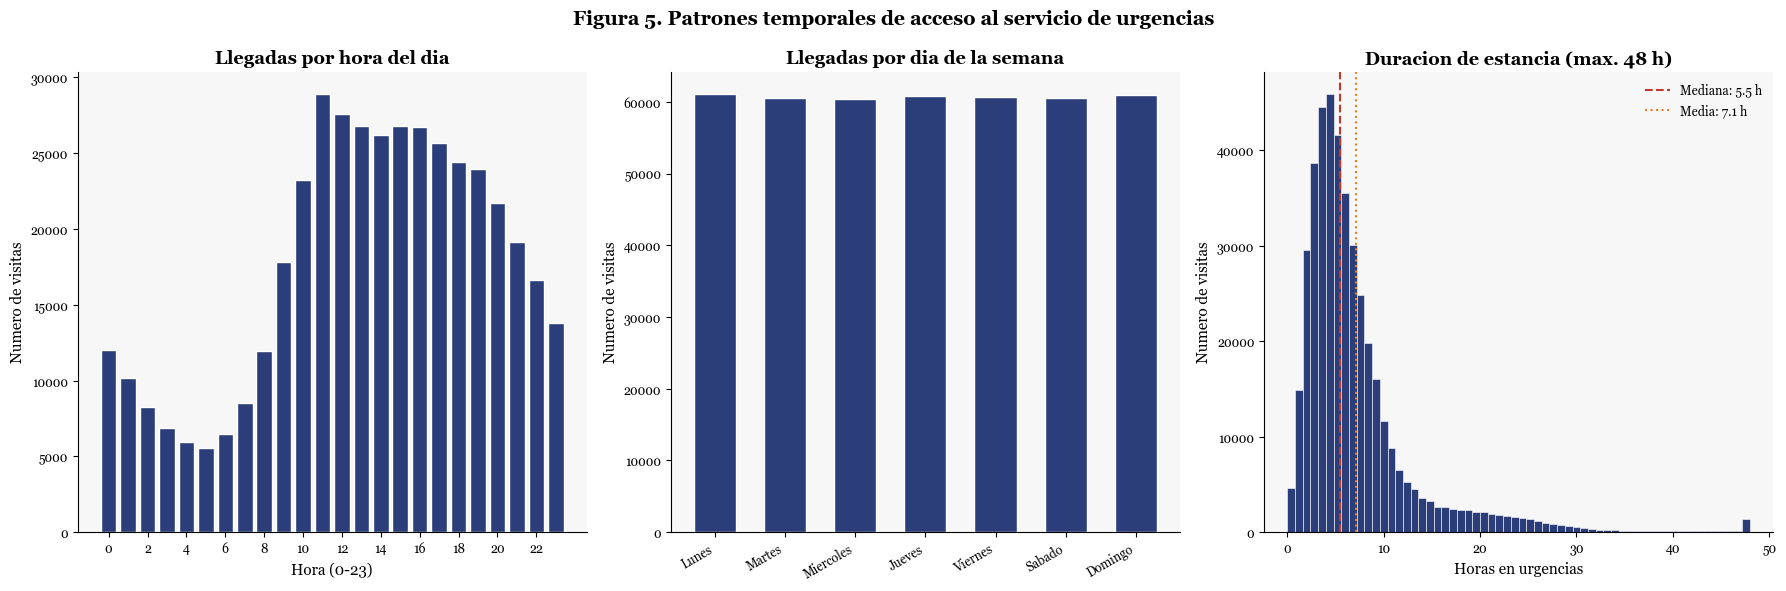

In [8]:
df_ed = dfs["edstays"].copy()
df_ed["intime"]  = pd.to_datetime(df_ed["intime"])
df_ed["outtime"] = pd.to_datetime(df_ed["outtime"])
df_ed["hora"]    = df_ed["intime"].dt.hour
df_ed["dia"]     = df_ed["intime"].dt.dayofweek
df_ed["los_h"]   = (df_ed["outtime"] - df_ed["intime"]).dt.total_seconds() / 3600

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "Figura 5. Patrones temporales de acceso al servicio de urgencias",
    fontsize=14, fontweight="bold"
)

# Llegadas por hora
llegadas_hora = df_ed["hora"].value_counts().sort_index()
axes[0].bar(llegadas_hora.index, llegadas_hora.values,
            color=AZUL_PRINCIPAL, edgecolor="white", width=0.8)
axes[0].set_title("Llegadas por hora del dia")
axes[0].set_xlabel("Hora (0-23)")
axes[0].set_ylabel("Numero de visitas")
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(axis="x", visible=False)

# Llegadas por dia semana
dias = ["Lunes", "Martes", "Miercoles", "Jueves",
        "Viernes", "Sabado", "Domingo"]
llegadas_dia = df_ed["dia"].value_counts().sort_index()
bars = axes[1].bar(dias, llegadas_dia.values,
                   color=AZUL_PRINCIPAL, edgecolor="white", width=0.6)
axes[1].set_title("Llegadas por dia de la semana")
axes[1].set_ylabel("Numero de visitas")
axes[1].set_xticklabels(dias, rotation=30, ha="right")
axes[1].grid(axis="x", visible=False)

# Duracion de estancia
los = df_ed["los_h"].clip(0, 48)
axes[2].hist(los, bins=60, color=AZUL_PRINCIPAL,
             edgecolor="white", linewidth=0.4)
mediana = los.median()
media   = los.mean()
axes[2].axvline(mediana, color="#C0392B", linewidth=1.5,
                linestyle="--", label=f"Mediana: {mediana:.1f} h")
axes[2].axvline(media,   color="#E67E22", linewidth=1.5,
                linestyle=":",  label=f"Media: {media:.1f} h")
axes[2].set_title("Duracion de estancia (max. 48 h)")
axes[2].set_xlabel("Horas en urgencias")
axes[2].set_ylabel("Numero de visitas")
axes[2].legend()
axes[2].grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

## 8. Heterogeneidad de los códigos diagnósticos: ICD-9 vs. ICD-10

MIMIC-IV-ED cubre visitas de 2011 a 2019, un período que abarca la transición del sistema de codificación ICD-9 al ICD-10 en Estados Unidos. Como resultado, la tabla `diagnosis` contiene diagnósticos codificados en dos nomenclaturas.

Esta figura ilustra el problema: los mismos procesos clínicos reciben nombres y códigos distintos según la versión. Ello impide usar los códigos crudos como features directamente, y motiva la unificación mediante el sistema CCS de la AHRQ que se realiza en las secciones siguientes.

C:\Users\CARLOS\AppData\Local\Temp\ipykernel_28384\3594727120.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_yticklabels(
C:\Users\CARLOS\AppData\Local\Temp\ipykernel_28384\3594727120.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_yticklabels(


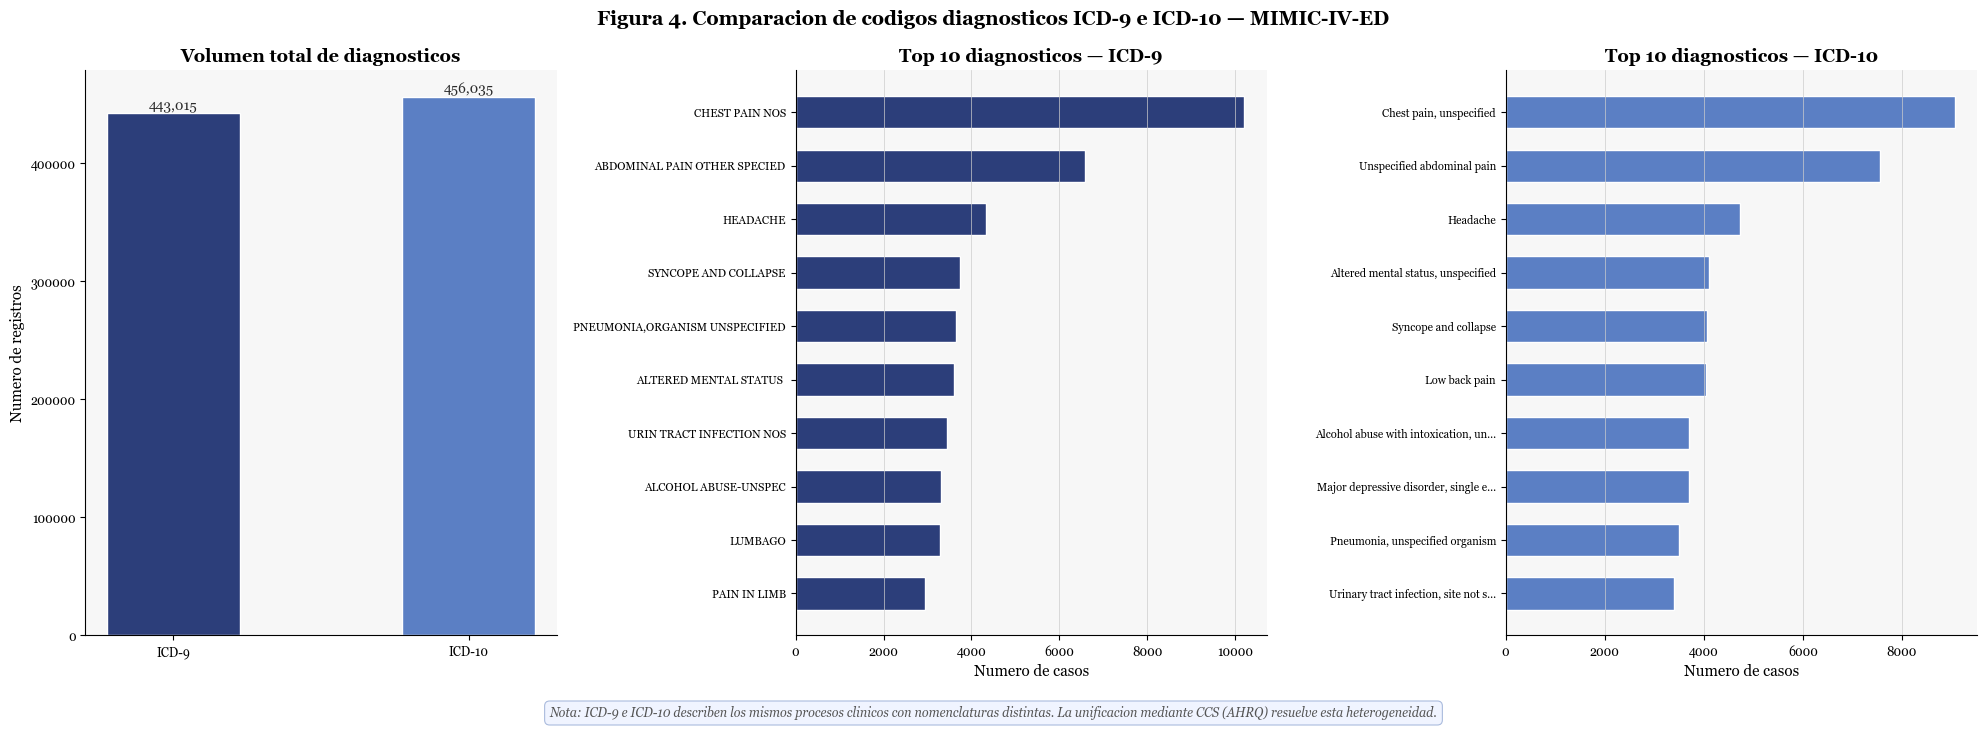

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(
    "Figura 4. Comparacion de codigos diagnosticos ICD-9 e ICD-10 — MIMIC-IV-ED",
    fontsize=14, fontweight="bold"
)

# Volumen por version
versiones = dfs["diagnosis"]["icd_version"].value_counts().sort_index()
bars = axes[0].bar(["ICD-9", "ICD-10"], versiones.values,
                   color=[AZUL_PRINCIPAL, AZUL_CLARO],
                   edgecolor="white", width=0.45)
axes[0].set_title("Volumen total de diagnosticos")
axes[0].set_ylabel("Numero de registros")
axes[0].grid(axis="x", visible=False)
for bar, val in zip(bars, versiones.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 3000,
                 f"{val:,}", ha="center", fontsize=10, color=GRIS_TEXTO)

# Top-10 ICD-9
top9 = (dfs["diagnosis"]
        .query("icd_version==9 and seq_num==1")["icd_title"]
        .value_counts().head(10))
axes[1].barh(top9.index, top9.values, color=AZUL_PRINCIPAL,
             edgecolor="white", height=0.6)
axes[1].set_title("Top 10 diagnosticos — ICD-9")
axes[1].set_xlabel("Numero de casos")
axes[1].invert_yaxis()
axes[1].set_yticklabels(
    [t[:35] + "..." if len(t) > 35 else t for t in top9.index],
    fontsize=8
)

# Top-10 ICD-10
top10 = (dfs["diagnosis"]
         .query("icd_version==10 and seq_num==1")["icd_title"]
         .value_counts().head(10))
axes[2].barh(top10.index, top10.values, color=AZUL_CLARO,
             edgecolor="white", height=0.6)
axes[2].set_title("Top 10 diagnosticos — ICD-10")
axes[2].set_xlabel("Numero de casos")
axes[2].invert_yaxis()
axes[2].set_yticklabels(
    [t[:35] + "..." if len(t) > 35 else t for t in top10.index],
    fontsize=8
)

note = (
    "Nota: ICD-9 e ICD-10 describen los mismos procesos clinicos con nomenclaturas distintas. "
    "La unificacion mediante CCS (AHRQ) resuelve esta heterogeneidad."
)
fig.text(0.5, -0.03, note, ha="center", fontsize=9, color="#555555",
         style="italic",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#F0F4FF",
                   edgecolor="#AABBDD", linewidth=0.8))

plt.tight_layout()
plt.show()

## 9. Unificación de diagnósticos: ICD-9 e ICD-10 → CCS

El *Clinical Classifications Software* (CCS) de la Agency for Healthcare Research and Quality (AHRQ) agrupa los más de 14.000 códigos ICD en 285 categorías clínicas mutuamente excluyentes y con significado clínico interpretable. Es el estándar utilizado en investigación clínica para normalizar diagnósticos heterogéneos.

### Archivos de referencia
- **ICD-9 → CCS**: `$dxref 2015.csv` (AHRQ, edición 2015)
- **ICD-10 → CCS**: `ccs_dx_icd10cm_2019_1.csv` (AHRQ, edición 2019)

Ambos ficheros requieren limpieza de comillas y espacios en los nombres de columna y valores antes de poder usarse en un merge.

In [10]:
ccs_icd9  = pd.read_csv("../data/raw/$dxref 2015.csv", skiprows=1)
ccs_icd10 = pd.read_csv("../data/raw/ccs_dx_icd10cm_2019_1.csv")

for df_ref in [ccs_icd9, ccs_icd10]:
    df_ref.columns = df_ref.columns.str.strip().str.strip("'")
    for col in df_ref.columns:
        if df_ref[col].dtype == object:
            df_ref[col] = df_ref[col].str.strip().str.strip("'")

### 9.1 Mapeo ICD → categoría CCS

Se trabaja exclusivamente con el **diagnóstico principal** (`seq_num == 1`) de cada visita, que es el que refleja el motivo de consulta primario y el que tiene sentido clínico como feature de contexto.

La normalización es distinta para cada versión:
- **ICD-9**: los códigos en MIMIC tienen longitud variable; el archivo de referencia AHRQ espera exactamente 5 caracteres con relleno de espacios por la derecha (`ljust(5)`). Sin este ajuste el merge no encuentra matches.
- **ICD-10**: merge directo sin transformación.

In [11]:
diag = dfs["diagnosis"].query("seq_num == 1").copy()

# ICD-9: normalizar con ljust (espacios a la derecha)
diag_9 = diag[diag["icd_version"] == 9].copy()
diag_9["icd_code_norm"] = diag_9["icd_code"].apply(
    lambda x: str(x).strip().ljust(5, ' ')
)
diag_9 = diag_9.merge(
    ccs_icd9[["ICD-9-CM CODE", "CCS CATEGORY", "CCS CATEGORY DESCRIPTION"]],
    left_on="icd_code_norm", right_on="ICD-9-CM CODE", how="left"
)

# ICD-10: directo
diag_10 = diag[diag["icd_version"] == 10].copy()
diag_10 = diag_10.merge(
    ccs_icd10[["ICD-10-CM CODE", "CCS CATEGORY", "CCS CATEGORY DESCRIPTION"]],
    left_on="icd_code", right_on="ICD-10-CM CODE", how="left"
)

# Unificar
diag_final = pd.concat([diag_9, diag_10], ignore_index=True)
diag_final["CCS CATEGORY"] = pd.to_numeric(diag_final["CCS CATEGORY"], errors="coerce")

print(f"% matcheados ICD-9:  {diag_9['CCS CATEGORY'].notna().mean()*100:.1f}%")
print(f"% matcheados ICD-10: {diag_10['CCS CATEGORY'].notna().mean()*100:.1f}%")

% matcheados ICD-9:  100.0%
% matcheados ICD-10: 100.0%


### 9.2 Construcción del label map CCS

Una vez obtenidas las categorías CCS para cada visita, se construye el *label map* definitivo con dos criterios:

1. **Nombre canónico**: para cada categoría CCS se toma la descripción más larga disponible, que generalmente corresponde a ICD-10 (descripciones más detalladas).
2. **Filtro de viabilidad**: se eliminan las categorías con menos de 1.000 casos en el dataset. Por debajo de ese umbral, un clasificador no tiene suficientes ejemplos para aprender patrones robustos.

In [12]:
# Nombre canónico por categoría (descripción más larga = ICD-10)
nombre_canonico = (
    diag_final.groupby("CCS CATEGORY")["CCS CATEGORY DESCRIPTION"]
    .apply(lambda x: max(x.dropna(), key=len) if x.notna().any() else "Unknown")
    .to_dict()
)
diag_final["ccs_nombre"] = diag_final["CCS CATEGORY"].map(nombre_canonico)

# Label map con filtro de clases viables
label_map_final = diag_final[["stay_id", "CCS CATEGORY", "ccs_nombre"]].copy()
label_map_final.columns = ["stay_id", "ccs_id", "ccs_nombre"]
label_map_final = label_map_final.dropna(subset=["ccs_id"])
label_map_final["ccs_id"] = label_map_final["ccs_id"].astype(int)

# Filtro mínimo 1000 casos
dist = label_map_final["ccs_nombre"].value_counts()
clases_viables = dist[dist >= 1000].index
label_map_final = label_map_final[label_map_final["ccs_nombre"].isin(clases_viables)]

print(f"stay_ids: {len(label_map_final):,} | Clases: {label_map_final['ccs_id'].nunique()} | Desbalance: {dist.max()//dist.min()}:1")

stay_ids: 392,172 | Clases: 83 | Desbalance: 32056:1


### 9.3 Distribución de las categorías CCS resultantes

Se visualiza la distribución completa del label map para evaluar el desbalance entre clases y apreciar simultáneamente las clases mayoritarias y las minoritarias.

RESUMEN DEL LABEL MAP CCS
  Total stays:          392,172
  Clases únicas:        83
  Ratio desbalance:     32056:1004 (31:1)
  Clase más frecuente:  Abdominal pain (32,056 casos)
  Clase menos frecuente:Administrative/social admission (1,004 casos)

DISTRIBUCIÓN COMPLETA (ccs_id | casos | % | nombre)
  [251] 32,056 (  8.2%)  ████████████████  Abdominal pain
  [102] 24,199 (  6.2%)  ████████████  Nonspecific chest pain
  [205] 14,809 (  3.8%)  ███████  Spondylosis; intervertebral disc disorders; other back problems
  [259] 11,445 (  2.9%)  █████  Residual codes; unclassified
  [133] 11,212 (  2.9%)  █████  Other lower respiratory disease
  [ 84] 10,614 (  2.7%)  █████  Headache; including migraine
  [211] 10,342 (  2.6%)  █████  Other connective tissue disease
  [660] 10,187 (  2.6%)  █████  Alcohol-related disorders
  [244]  9,386 (  2.4%)  ████  Other injuries and conditions due to external causes
  [197]  9,191 (  2.3%)  ████  Skin and subcutaneous tissue infections
  [204]  8,757 

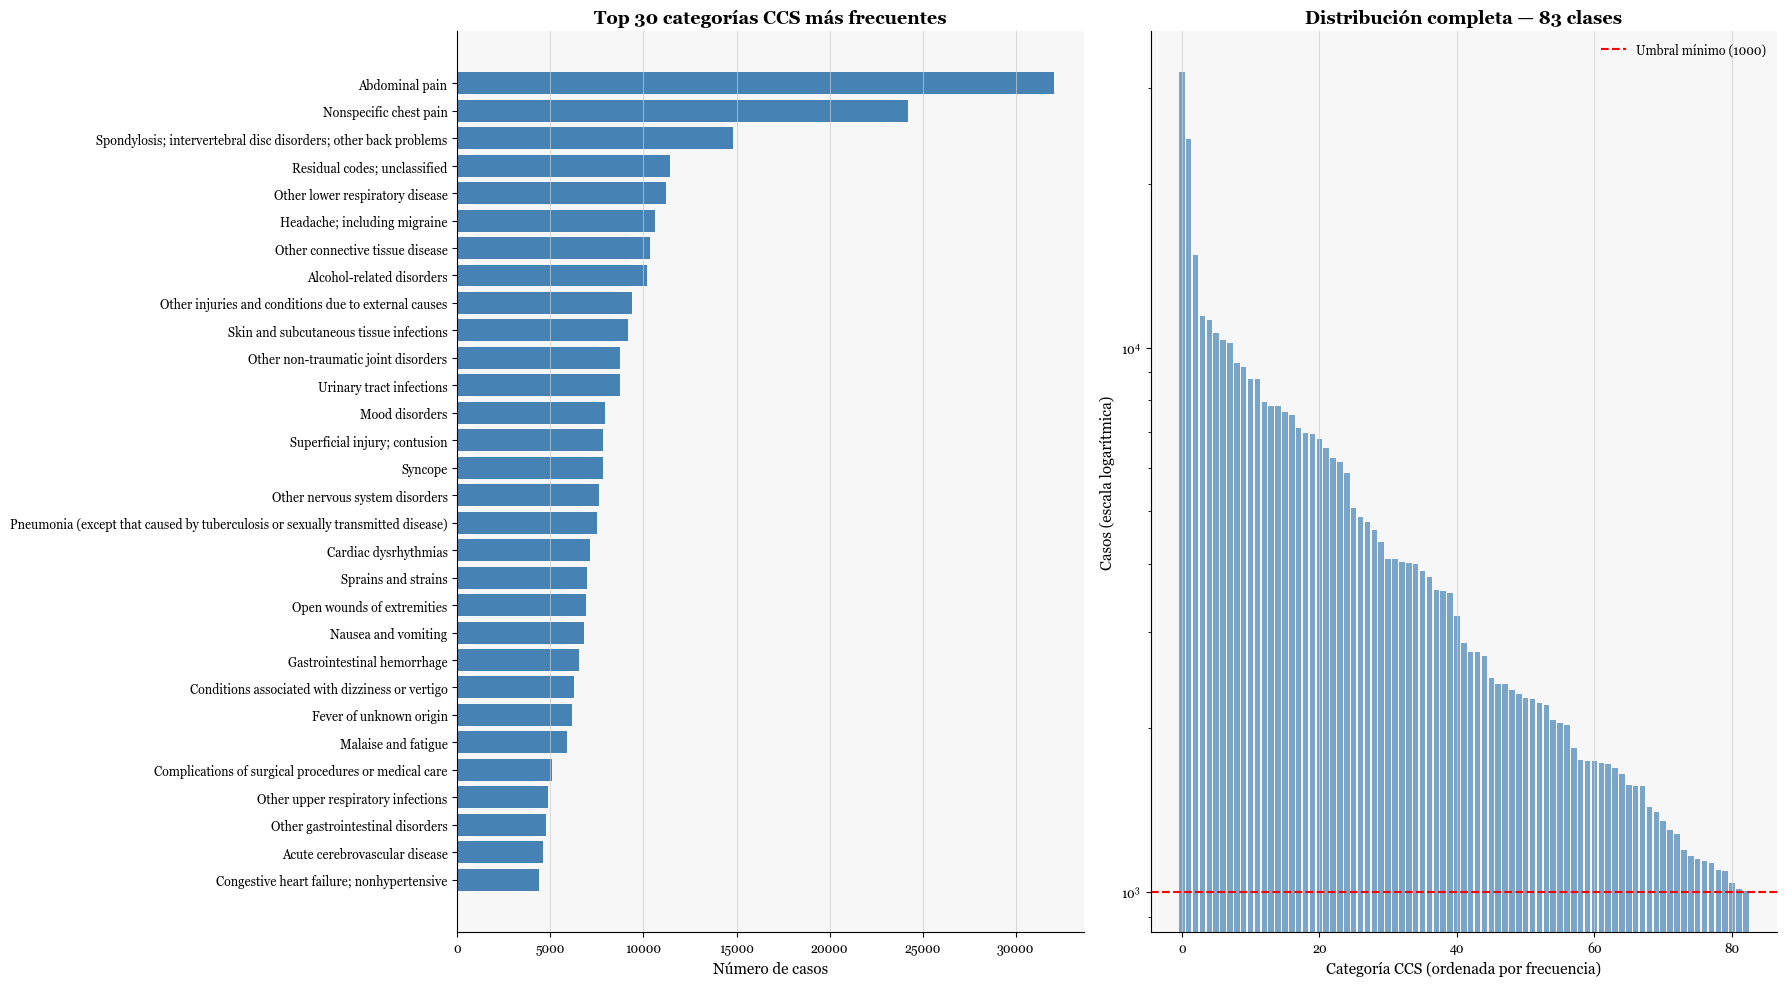

In [13]:
import matplotlib.pyplot as plt

dist = label_map_final["ccs_nombre"].value_counts()

print("=" * 70)
print(f"RESUMEN DEL LABEL MAP CCS")
print("=" * 70)
print(f"  Total stays:          {len(label_map_final):,}")
print(f"  Clases únicas:        {label_map_final['ccs_id'].nunique()}")
print(f"  Ratio desbalance:     {dist.max()}:{dist.min()} ({dist.max()//dist.min()}:1)")
print(f"  Clase más frecuente:  {dist.index[0]} ({dist.iloc[0]:,} casos)")
print(f"  Clase menos frecuente:{dist.index[-1]} ({dist.iloc[-1]:,} casos)")

print("\n" + "=" * 70)
print("DISTRIBUCIÓN COMPLETA (ccs_id | casos | % | nombre)")
print("=" * 70)

resumen = (
    label_map_final
    .groupby(["ccs_id", "ccs_nombre"])
    .size()
    .reset_index(name="casos")
    .sort_values("casos", ascending=False)
)
resumen["pct"] = (resumen["casos"] / len(label_map_final) * 100).round(2)

for _, row in resumen.iterrows():
    barra = "█" * int(row["pct"] * 2)
    print(f"  [{int(row['ccs_id']):>3}] {row['casos']:>6,} ({row['pct']:>5.1f}%)  {barra}  {row['ccs_nombre']}")

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Izquierda: barplot horizontal top-30
top30 = resumen.head(30)
axes[0].barh(top30["ccs_nombre"], top30["casos"], color="steelblue")
axes[0].set_xlabel("Número de casos")
axes[0].set_title("Top 30 categorías CCS más frecuentes")
axes[0].invert_yaxis()

# Derecha: distribución completa en escala log
axes[1].bar(range(len(resumen)), resumen["casos"], color="steelblue", alpha=0.7)
axes[1].set_yscale("log")
axes[1].set_xlabel("Categoría CCS (ordenada por frecuencia)")
axes[1].set_ylabel("Casos (escala logarítmica)")
axes[1].set_title(f"Distribución completa — {len(resumen)} clases")
axes[1].axhline(y=1000, color="red", linestyle="--", label="Umbral mínimo (1000)")
axes[1].legend()

plt.tight_layout()
plt.show()

### 9.4 Visualización del proceso de unificación ICD → CCS

Esta figura resume el proceso completo de normalización: el estado *antes* (ICD-9 e ICD-10 con vocabularios incompatibles) y el estado *después* (un único espacio numérico CCS compartido). 

C:\Users\CARLOS\AppData\Local\Temp\ipykernel_28384\1940573505.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(short9, fontsize=8)
C:\Users\CARLOS\AppData\Local\Temp\ipykernel_28384\1940573505.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(short10, fontsize=8)
C:\Users\CARLOS\AppData\Local\Temp\ipykernel_28384\1940573505.py:90: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels(short_ccs, fontsize=8.5)


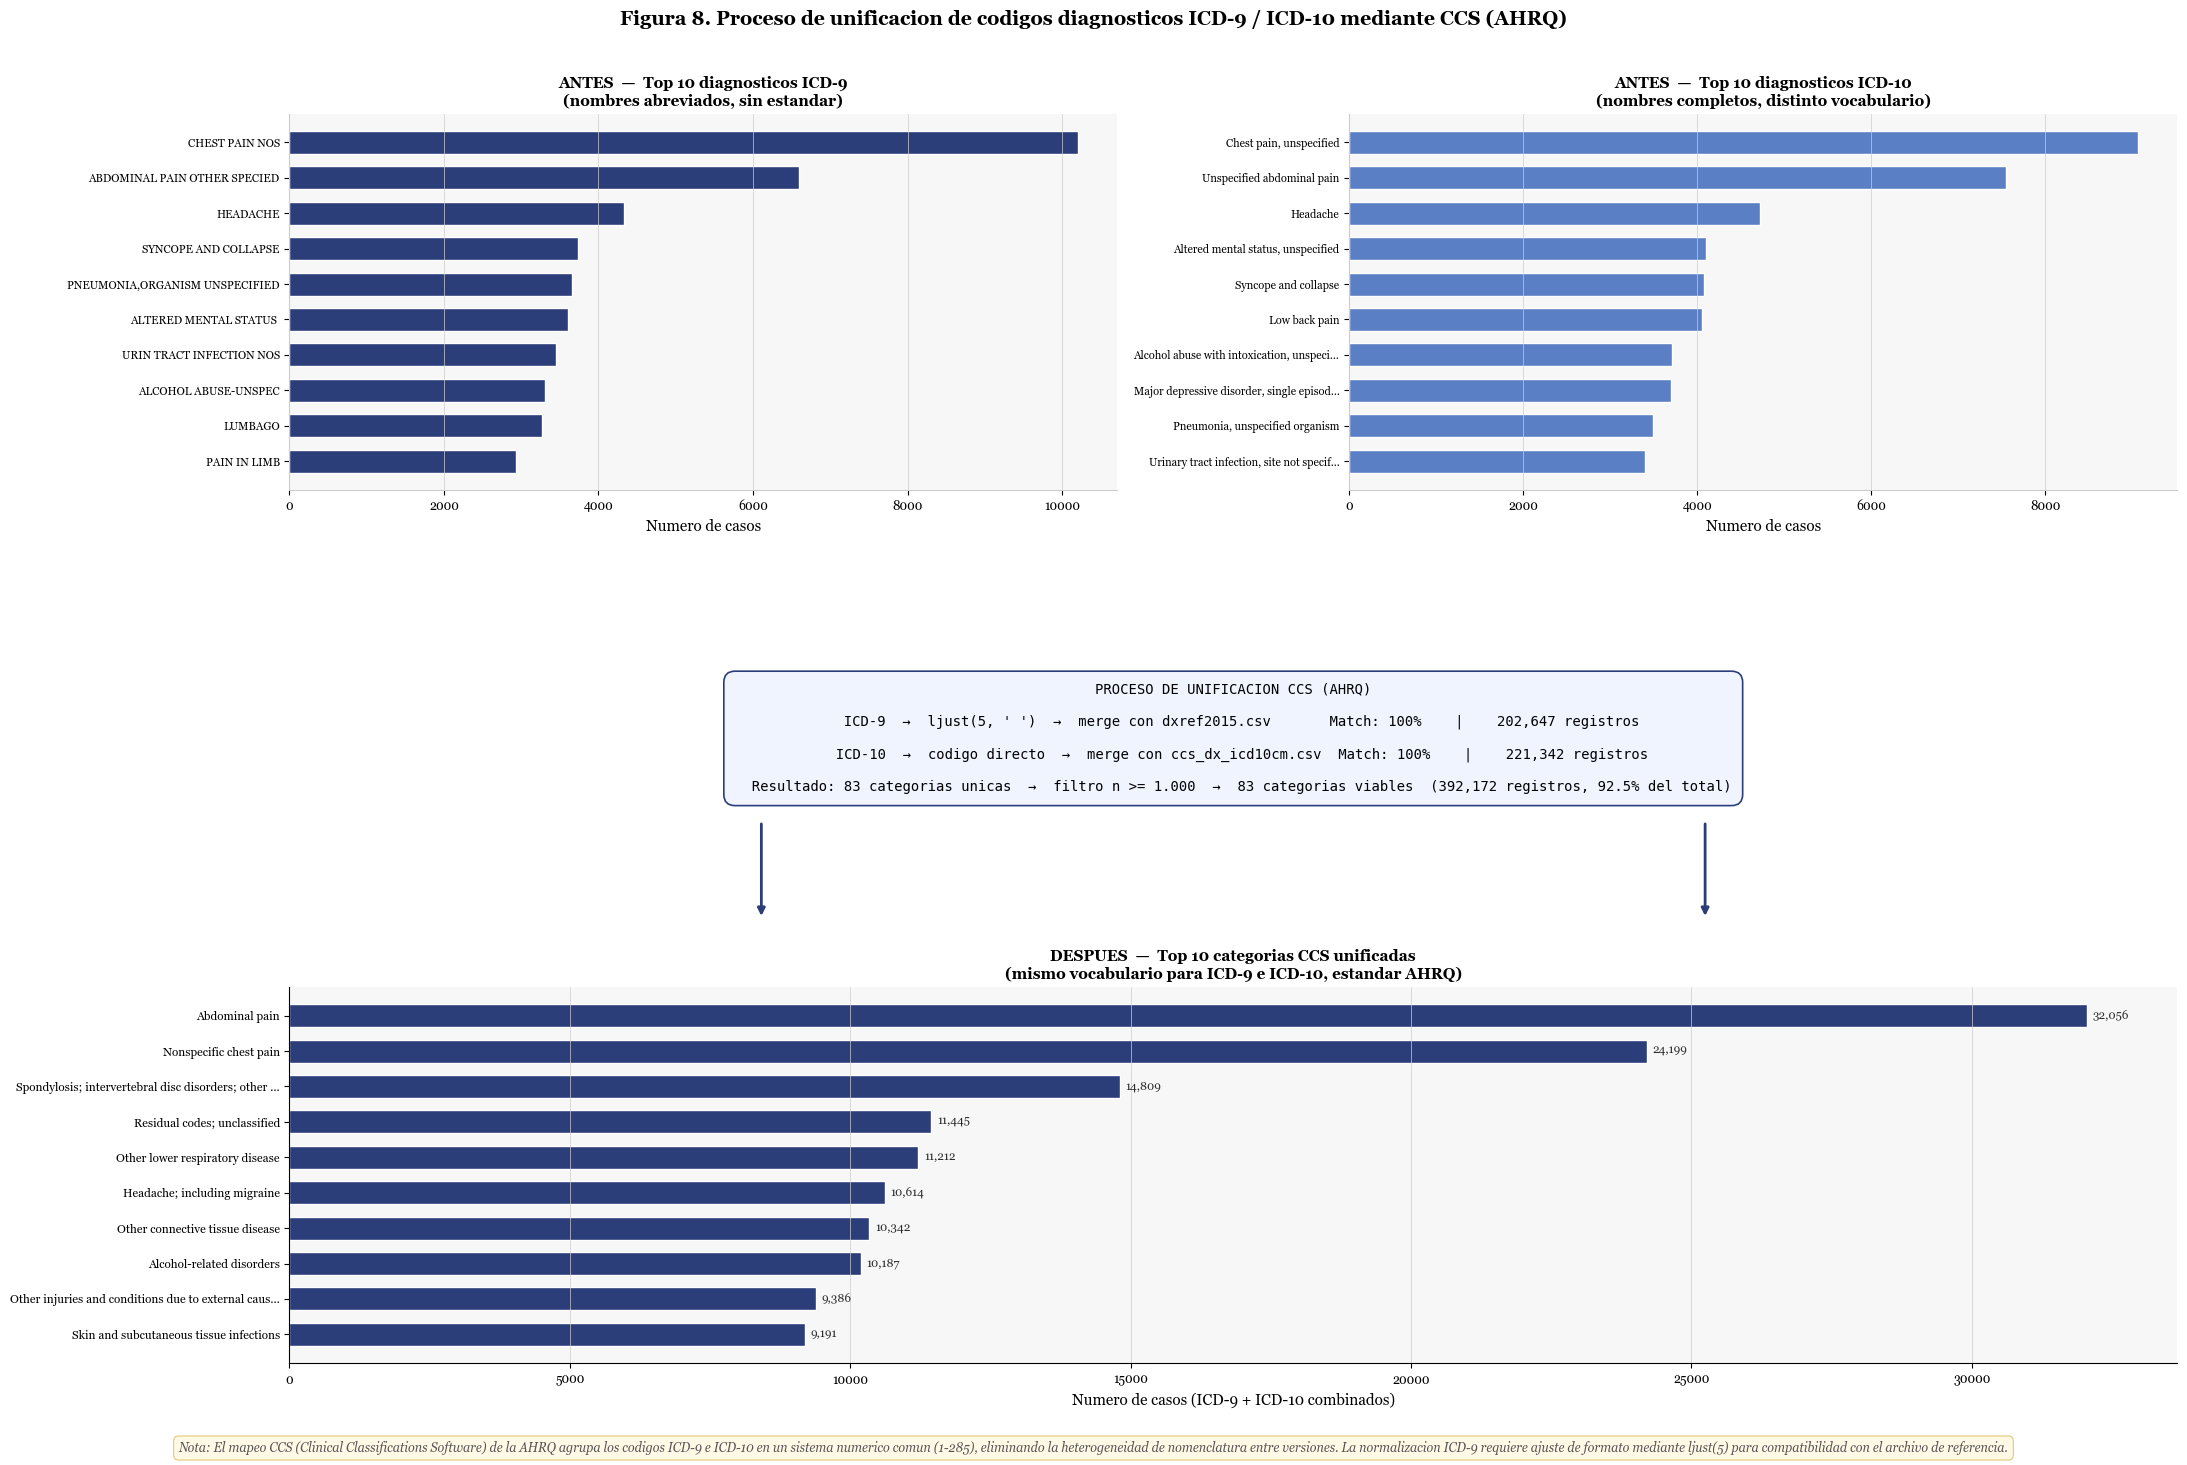

In [14]:
diag_viz = dfs["diagnosis"].query("seq_num == 1").copy()

# Estado ANTES: ICD-9 e ICD-10 por separado
top_icd9  = (diag_viz.query("icd_version == 9")["icd_title"]
             .value_counts().head(10))
top_icd10 = (diag_viz.query("icd_version == 10")["icd_title"]
             .value_counts().head(10))

# Estado DESPUES: CCS unificado
top_ccs = label_map_final["ccs_nombre"].value_counts().head(10)

fig = plt.figure(figsize=(22, 14))
fig.suptitle(
    "Figura 8. Proceso de unificacion de codigos diagnosticos ICD-9 / ICD-10"
    " mediante CCS (AHRQ)",
    fontsize=14, fontweight="bold", y=1.01
)

# ── Fila 1: ANTES ────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(3, 2, 1)
ax2 = fig.add_subplot(3, 2, 2)

short9  = [t[:40] + "..." if len(t) > 40 else t for t in top_icd9.index]
short10 = [t[:40] + "..." if len(t) > 40 else t for t in top_icd10.index]

ax1.barh(short9,  top_icd9.values,  color=AZUL_PRINCIPAL,
         edgecolor="white", height=0.65)
ax1.set_title("ANTES  —  Top 10 diagnosticos ICD-9\n(nombres abreviados, sin estandar)",
              fontsize=11)
ax1.set_xlabel("Numero de casos")
ax1.set_yticklabels(short9, fontsize=8)
ax1.invert_yaxis()
ax1.grid(axis="y", visible=False)

ax2.barh(short10, top_icd10.values, color=AZUL_CLARO,
         edgecolor="white", height=0.65)
ax2.set_title("ANTES  —  Top 10 diagnosticos ICD-10\n(nombres completos, distinto vocabulario)",
              fontsize=11)
ax2.set_xlabel("Numero de casos")
ax2.set_yticklabels(short10, fontsize=8)
ax2.invert_yaxis()
ax2.grid(axis="y", visible=False)

# Separador visual entre ANTES y DESPUES
for spine in ["top", "bottom", "left", "right"]:
    for ax in [ax1, ax2]:
        ax.spines[spine].set_edgecolor("#CCCCCC")

# ── Fila 2: Flecha y estadisticas del proceso ─────────────────────────────────
ax_mid = fig.add_subplot(3, 1, 2)
ax_mid.axis("off")

stats_text = (
    "PROCESO DE UNIFICACION CCS (AHRQ)\n\n"
    f"  ICD-9  →  ljust(5, ' ')  →  merge con dxref2015.csv       "
    f"Match: 100%    |    {diag_viz.query('icd_version==9').shape[0]:,} registros\n\n"
    f"  ICD-10  →  codigo directo  →  merge con ccs_dx_icd10cm.csv  "
    f"Match: 100%    |    {diag_viz.query('icd_version==10').shape[0]:,} registros\n\n"
    f"  Resultado: {label_map_final['ccs_id'].nunique()} categorias unicas  "
    f"→  filtro n >= 1.000  →  83 categorias viables  "
    f"({len(label_map_final):,} registros, 92.5% del total)"
)

ax_mid.text(0.5, 0.5, stats_text,
            ha="center", va="center", fontsize=10,
            transform=ax_mid.transAxes,
            bbox=dict(boxstyle="round,pad=0.8", facecolor="#F0F4FF",
                      edgecolor="#2C3E7A", linewidth=1.2),
            fontfamily="monospace")

# Flechas
for x in [0.25, 0.75]:
    ax_mid.annotate("", xy=(x, 0.02), xytext=(x, 0.28),
                    xycoords="axes fraction", textcoords="axes fraction",
                    arrowprops=dict(arrowstyle="-|>", color=AZUL_PRINCIPAL,
                                   lw=2.0))

# ── Fila 3: DESPUES ───────────────────────────────────────────────────────────
ax3 = fig.add_subplot(3, 1, 3)

short_ccs = [t[:50] + "..." if len(t) > 50 else t for t in top_ccs.index]
bars = ax3.barh(short_ccs, top_ccs.values,
                color=AZUL_PRINCIPAL, edgecolor="white", height=0.65)
ax3.set_title(
    "DESPUES  —  Top 10 categorias CCS unificadas\n"
    "(mismo vocabulario para ICD-9 e ICD-10, estandar AHRQ)",
    fontsize=11
)
ax3.set_xlabel("Numero de casos (ICD-9 + ICD-10 combinados)")
ax3.set_yticklabels(short_ccs, fontsize=8.5)
ax3.invert_yaxis()
ax3.grid(axis="y", visible=False)
for bar, val in zip(bars, top_ccs.values):
    ax3.text(val + 100, bar.get_y() + bar.get_height() / 2,
             f"{val:,}", va="center", fontsize=8.5, color=GRIS_TEXTO)

note = (
    "Nota: El mapeo CCS (Clinical Classifications Software) de la AHRQ agrupa los "
    "codigos ICD-9 e ICD-10 en un sistema numerico comun (1-285), eliminando la "
    "heterogeneidad de nomenclatura entre versiones. La normalizacion ICD-9 requiere "
    "ajuste de formato mediante ljust(5) para compatibilidad con el archivo de referencia."
)
fig.text(0.5, -0.02, note, ha="center", fontsize=9, color="#555555",
         style="italic",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#FFF9E6",
                   edgecolor="#E0C97A", linewidth=0.8))

plt.tight_layout()
plt.show()

## 10. Análisis de la medicación previa (medrecon)

Antes de definir los flags binarios de medicación que se incluirán en el modelo, se realiza un análisis de frecuencia de las clases farmacológicas presentes en `medrecon`. El objetivo es identificar qué clases tienen suficiente prevalencia para ser informativas como features y descartar las que son demasiado raras.

In [15]:
# Ver todas las clases con >5000 registros
print(dfs["medrecon"]["etcdescription"].value_counts()
      .loc[lambda x: x > 5000]
      .to_string())

etcdescription
Antihyperlipidemic - HMG CoA Reductase Inhibitors (statins)               102285
Gastric Acid Secretion Reducing Agents - Proton Pump Inhibitors (PPIs)     93308
Salicylate Analgesics                                                      87881
Platelet Aggregation Inhibitors - Salicylates                              87178
Vitamins - D Derivatives                                                   69988
Beta Blockers Cardiac Selective                                            68528
Benzodiazepines                                                            63188
Antianxiety Agent - Benzodiazepines                                        61048
Analgesic Opioid Agonists                                                  60904
Antidepressant - Selective Serotonin Reuptake Inhibitors (SSRIs)           58271
Asthma/COPD Therapy - Beta 2-Adrenergic Agents, Inhaled, Short Acting      57019
ACE Inhibitors                                                             56130
Medical Suppl

In [16]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Todas las clases con al menos 1000 registros
dist_meds = (
    dfs["medrecon"]["etcdescription"]
    .value_counts()
    .loc[lambda x: x >= 1000]
    .reset_index()
)
dist_meds.columns = ["clase", "n_registros"]
dist_meds["pct_stays"] = dist_meds["n_registros"] / len(dfs["edstays"]) * 100

print(f"Clases con >= 1000 registros: {len(dist_meds)}")
print(f"Clases con >= 5000 registros: {(dist_meds['n_registros'] >= 5000).sum()}")
print(f"Clases con >= 10000 registros: {(dist_meds['n_registros'] >= 10000).sum()}")
print(f"\n% stays con AL MENOS 1 medicamento: "
      f"{dfs['medrecon']['stay_id'].nunique() / len(dfs['edstays']) * 100:.1f}%")

Clases con >= 1000 registros: 290
Clases con >= 5000 registros: 120
Clases con >= 10000 registros: 67

% stays con AL MENOS 1 medicamento: 72.3%


### 10.1 Número de clases farmacológicas distintas por visita

Se analiza cuántas clases farmacológicas distintas registra de media cada paciente. Esta estadística informa sobre la complejidad del perfil de medicación previa y justifica el uso de flags binarios por clase en lugar de intentar codificar el listado completo de fármacos.

In [17]:
meds_por_stay = (
    dfs["medrecon"]
    .groupby("stay_id")["etcdescription"]
    .nunique()
    .reset_index(name="n_clases_distintas")
)

print("=== CLASES FARMACOLÓGICAS DISTINTAS POR VISITA ===")
print(meds_por_stay["n_clases_distintas"].describe().round(1))
print(f"\nVisitas con 0 clases distintas: "
      f"{len(dfs['edstays']) - len(meds_por_stay):,} "
      f"({(len(dfs['edstays']) - len(meds_por_stay))/len(dfs['edstays'])*100:.1f}%)")

=== CLASES FARMACOLÓGICAS DISTINTAS POR VISITA ===
count    307196.0
mean          9.2
std           7.1
min           0.0
25%           3.0
50%           8.0
75%          13.0
max          73.0
Name: n_clases_distintas, dtype: float64

Visitas con 0 clases distintas: 117,891 (27.7%)


### 10.2 Selección del umbral de inclusión de clases farmacológicas

Para decidir qué clases incluir como features binarias, se analizan tres perspectivas complementarias:
- **Frecuencia absoluta** (nº de registros): ¿cuántas veces aparece cada clase en el dataset?
- **Cobertura de visitas** (% de stays): ¿qué porcentaje de pacientes toma al menos un fármaco de esa clase?
- **Cobertura acumulada**: ¿cuántas clases necesito para cubrir el X% de los registros totales?

Este análisis justifica la selección final de los 30 grupos farmacológicos definidos en `GRUPOS_FARMA` del `loader.py`.

C:\Users\CARLOS\AppData\Local\Temp\ipykernel_28384\1076994422.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_yticklabels(
C:\Users\CARLOS\AppData\Local\Temp\ipykernel_28384\1076994422.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_yticklabels(


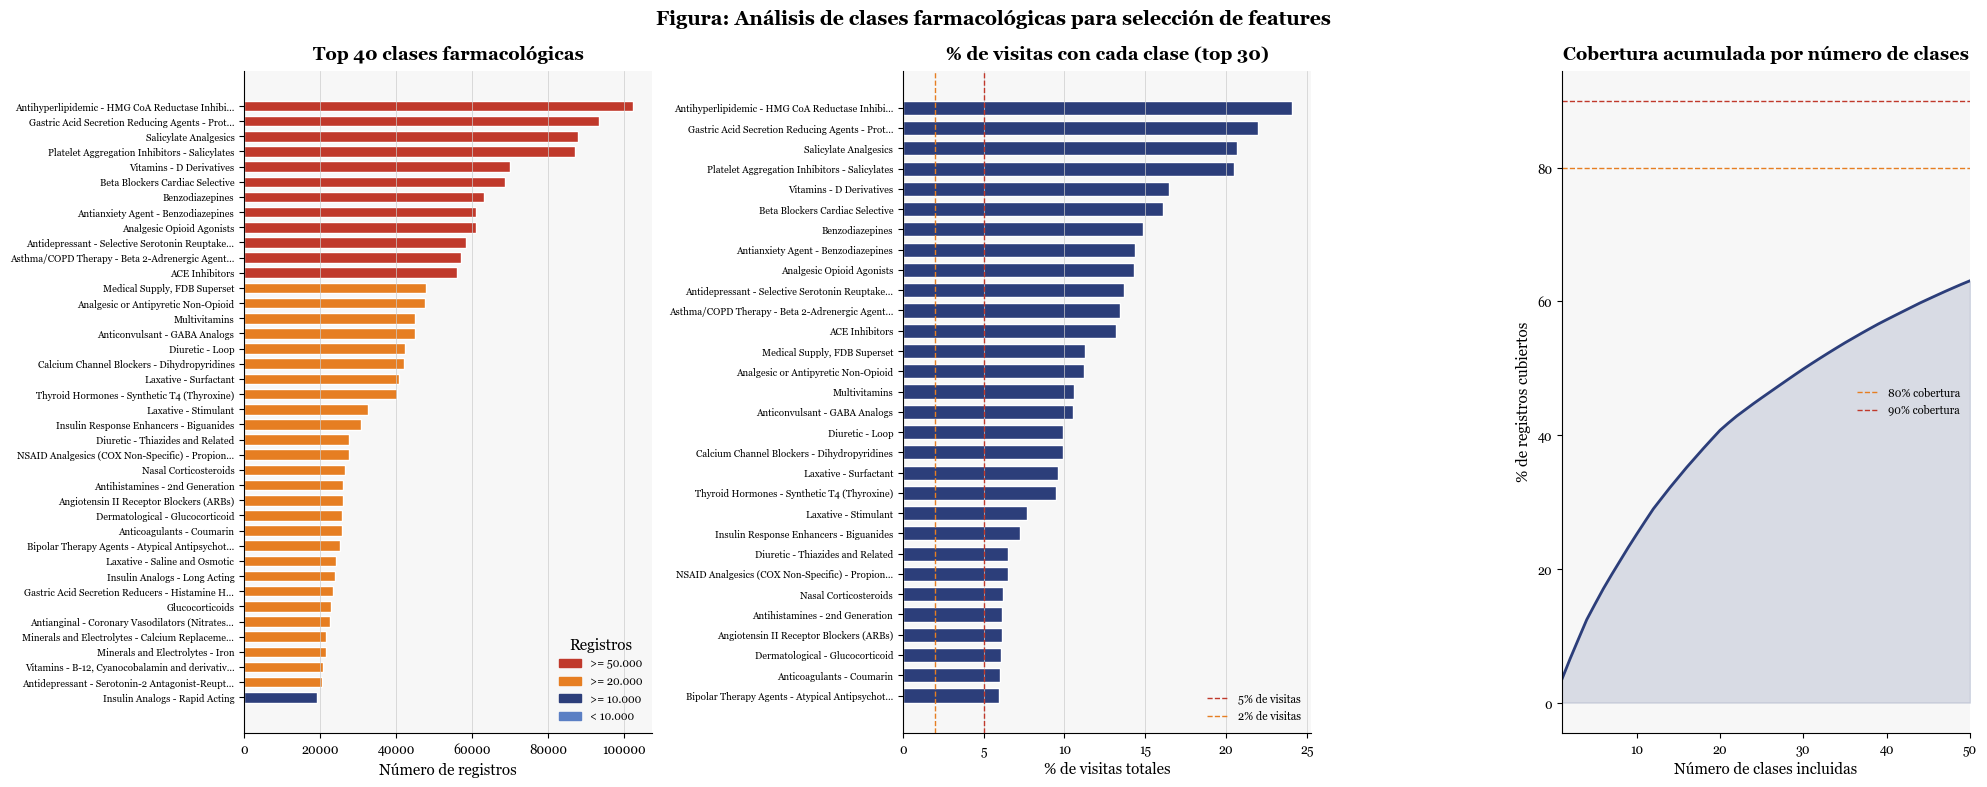

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle(
    "Figura: Análisis de clases farmacológicas para selección de features",
    fontsize=14, fontweight="bold"
)

AZUL_PRINCIPAL = "#2C3E7A"
AZUL_CLARO     = "#5B7FC4"
GRIS_TEXTO     = "#2B2B2B"

# ── Izquierda: Top-40 clases por frecuencia ───────────────────────────────────
top40 = dist_meds.head(40)
colores = [
    "#C0392B" if r >= 50000
    else "#E67E22" if r >= 20000
    else "#2C3E7A" if r >= 10000
    else "#5B7FC4"
    for r in top40["n_registros"]
]
bars = axes[0].barh(
    top40["clase"].apply(lambda x: x[:45] + "..." if len(x) > 45 else x),
    top40["n_registros"],
    color=colores, edgecolor="white", height=0.7
)
axes[0].invert_yaxis()
axes[0].set_xlabel("Número de registros")
axes[0].set_title("Top 40 clases farmacológicas", pad=8)
axes[0].set_yticklabels(
    [x[:45] + "..." if len(x) > 45 else x for x in top40["clase"]],
    fontsize=7
)
axes[0].grid(axis="y", visible=False)

# Leyenda de colores
from matplotlib.patches import Patch
leyenda = [
    Patch(color="#C0392B", label=">= 50.000"),
    Patch(color="#E67E22", label=">= 20.000"),
    Patch(color="#2C3E7A", label=">= 10.000"),
    Patch(color="#5B7FC4", label="< 10.000"),
]
axes[0].legend(handles=leyenda, title="Registros", fontsize=8, loc="lower right")

# ── Centro: % de stays que toman cada clase (top-30) ─────────────────────────
top30 = dist_meds.head(30)
axes[1].barh(
    top30["clase"].apply(lambda x: x[:45] + "..." if len(x) > 45 else x),
    top30["pct_stays"],
    color=AZUL_PRINCIPAL, edgecolor="white", height=0.7
)
axes[1].invert_yaxis()
axes[1].set_xlabel("% de visitas totales")
axes[1].set_title("% de visitas con cada clase (top 30)", pad=8)
axes[1].set_yticklabels(
    [x[:45] + "..." if len(x) > 45 else x for x in top30["clase"]],
    fontsize=7
)
axes[1].axvline(5, color="#C0392B", linewidth=1, linestyle="--",
                label="5% de visitas")
axes[1].axvline(2, color="#E67E22", linewidth=1, linestyle="--",
                label="2% de visitas")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", visible=False)

# ── Derecha: distribución acumulada ──────────────────────────────────────────
n_clases = range(1, min(51, len(dist_meds) + 1))
cobertura = [
    dist_meds.head(n)["n_registros"].sum() / dfs["medrecon"].shape[0] * 100
    for n in n_clases
]
axes[2].plot(list(n_clases), cobertura,
             color=AZUL_PRINCIPAL, linewidth=2)
axes[2].fill_between(list(n_clases), cobertura, alpha=0.15, color=AZUL_PRINCIPAL)
axes[2].axhline(80, color="#E67E22", linewidth=1, linestyle="--", label="80% cobertura")
axes[2].axhline(90, color="#C0392B", linewidth=1, linestyle="--", label="90% cobertura")

# Marcar cuántas clases necesitas para cada umbral
for umbral, color in [(80, "#E67E22"), (90, "#C0392B")]:
    n_necesarias = next((n for n, c in zip(n_clases, cobertura) if c >= umbral), None)
    if n_necesarias:
        axes[2].axvline(n_necesarias, color=color, linewidth=1, linestyle=":")
        axes[2].text(n_necesarias + 0.5, umbral - 5,
                     f"{n_necesarias} clases\n→ {umbral}% cobertura",
                     fontsize=8, color=color)

axes[2].set_xlabel("Número de clases incluidas")
axes[2].set_ylabel("% de registros cubiertos")
axes[2].set_title("Cobertura acumulada por número de clases", pad=8)
axes[2].legend(fontsize=8)
axes[2].set_xlim(1, 50)
axes[2].grid(axis="x", visible=False)

plt.tight_layout()
plt.savefig("../notebooks/fig_medicacion_seleccion_clases.png", dpi=300)
plt.show()

### 10.3 Definición final de los grupos farmacológicos

Se define el diccionario `GRUPOS_FARMA_CANDIDATOS` con los 30 grupos seleccionados, organizados por sistema orgánico. Para cada grupo se especifica el patrón de búsqueda sobre `etcdescription` y el número de registros que cubre en el dataset, lo que permite verificar que todos tienen suficiente representación.

Nótese el uso de *lookbehind negativo* en `med_corticoide_sist` para excluir corticoides dermatológicos e inhalados, que tienen un perfil clínico completamente distinto a los sistémicos.

In [19]:
GRUPOS_FARMA_CANDIDATOS = {
    # ── Cardiovascular & Riesgo de Sangrado (Críticos para Triaje) ────────
    "med_estatina":          ("HMG CoA Reductase Inhibitors",    102_285),
    "med_antiagregante":     ("Platelet Aggregation Inhibitors|Salicylate Analgesics", 87_178),
    "med_anticoagulante":    ("Anticoagulant|Direct Factor Xa Inhibitors|Low Molecular Weight Heparins", 25_665),
    "med_betabloqueante":    ("Beta Blockers",                   68_528),
    "med_ieca_ara2":         ("ACE Inhibitors|Angiotensin II Receptor Blockers", 56_130),
    "med_calcioantagonista": ("Calcium Channel Blockers",        42_187),
    "med_nitrato":           ("Coronary Vasodilators",           22_576),
    "med_alfa_bloqueante":   ("Alpha-1 Receptor Blockers|alpha-1-Adrenoceptor Antagonists", 15_334),

    # ── Respiratorio ──────────────────────────────────────────────────────
    "med_broncodilatador":   ("Asthma/COPD Therapy|Asthma Therapy", 57_019),
    "med_corticoide_inhal":  ("Inhaled Corticosteroids",         16_350),

    # ── Metabólico / Endocrino ────────────────────────────────────────────
    "med_insulina":          ("Insulin Analogs",                 23_826),
    "med_antidiabetico_oral":("Biguanides|Sulfonylurea Derivatives", 30_887),
    "med_tiroides":          ("Thyroid Hormones",                40_276),

    # ── Neurológico / Psiquiátrico ────────────────────────────────────────
    "med_benzodiacepina":    ("Benzodiazepines",                 63_188),
    "med_opioide":           ("Opioid",                          60_904),
    "med_antidepresivo":     ("Reuptake Inhibitors|Alpha-2 Receptor Antagonists|Tricyclics", 58_271),
    "med_anticonvulsivo":    ("Anticonvulsant",                  44_880),
    "med_antipsicotico":     ("Antipsychotic|Bipolar Therapy Agents", 25_282),
    "med_estimulante_snc":   ("Attention Deficit-Hyperactivity|CNS Stimulant", 10_170),
    "med_sedante_hipnotico": ("Sedative-Hypnotic|Hypnotics",     10_100),

    # ── Dolor / Inflamación / Inmunidad ───────────────────────────────────
    "med_aine":              ("NSAID Analgesics",                27_622),
    "med_analgesico_suave":  ("Analgesic or Antipyretic Non-Opioid", 47_582),  # Bien acotado, Aspirina no solapa aquí


    # Lookbehind negativo para "Dermatological - Glucocorticoids" y ancla de inicio para no capturar subcategorías compuestas como "Inhaled Corticosteroids".
    "med_corticoide_sist":   (r"(?<!Dermatological - )(?<!Inhaled )Glucocorticoids", 22_939),  # Solo sistémicos (pastillas/inyecciones)

    "med_inmunosupresor":    ("Immunosuppressive",               6_497),

    # ── Renal / Diuréticos ────────────────────────────────────────────────
    "med_diuretico":         ("Diuretic|Aldosterone Receptor Antagonists", 42_204),

    # ── Gastrointestinal ──────────────────────────────────────────────────
    "med_antiacido":         ("Proton Pump Inhibitors|Histamine H2-Receptor Antagonists", 93_308),
    "med_laxante":           ("Laxative",                        40_797),
    "med_antiemetico":       ("Antiemetic",                      18_625),

    # ── Alergias / Otros ──────────────────────────────────────────────────
    "med_antihistaminico":   ("Antihistamines",                  26_025),
    "med_antibiotico":       ("Fluoroquinolone Antibiotics|Antibacterial", 5_739),
}

## 11. Persistencia de artefactos intermedios

Se guardan en `data/interim/` los tres artefactos que el resto del pipeline necesita:

- **`label_map_ccs.parquet`**: mapeo `stay_id → ccs_id + ccs_nombre`
- **`ccs_icd9_clean.parquet`** y **`ccs_icd10_clean.parquet`**: tablas de referencia CCS limpias, usadas por `loader.py` para generar la columna `ccs_category` en el dataset base.

> **Nota**: este notebook debe ejecutarse antes de `loader.py`. Si los parquets no existen, el loader lanzará un `FileNotFoundError`.

In [20]:
import os
os.makedirs("../data/interim", exist_ok=True)

label_map_final.to_parquet("../data/interim/label_map_ccs.parquet", index=False)
ccs_icd9.to_parquet("../data/interim/ccs_icd9_clean.parquet",   index=False)
ccs_icd10.to_parquet("../data/interim/ccs_icd10_clean.parquet", index=False)

print("Guardados en data/interim/")
print(f"  label_map_ccs.parquet  → {len(label_map_final):,} filas")
print(f"  ccs_icd9_clean.parquet → {len(ccs_icd9):,} filas")
print(f"  ccs_icd10_clean.parquet→ {len(ccs_icd10):,} filas")

Guardados en data/interim/
  label_map_ccs.parquet  → 392,172 filas
  ccs_icd9_clean.parquet → 15,073 filas
  ccs_icd10_clean.parquet→ 72,446 filas


## 12. Validación: comparación con PyHealth

Como control de calidad del mapeo ICD → CCS implementado manualmente, se compara con el resultado de la librería PyHealth, que implementa el mismo mapeo de forma independiente. Se evalúan dos métricas:
- **Tasa de match**: porcentaje de códigos que PyHealth consigue mapear (vs. nuestro merge con los CSV de la AHRQ).
- **Concordancia**: porcentaje de casos donde ambos métodos asignan la misma categoría CCS.

In [21]:
# Instalar con uv, no con pip
import subprocess
subprocess.run(["uv", "pip", "install", "pyhealth"], check=True)

CompletedProcess(args=['uv', 'pip', 'install', 'pyhealth'], returncode=0)

In [22]:
from pyhealth.medcode import CrossMap

mapper_9  = CrossMap(source_vocabulary="ICD9CM",  target_vocabulary="CCSCM")
mapper_10 = CrossMap(source_vocabulary="ICD10CM", target_vocabulary="CCSCM")

# Aplicar a tu diagnosis
diag = dfs["diagnosis"].query("seq_num == 1").copy()

def mapear_con_pyhealth(row):
    try:
        if row["icd_version"] == 9:
            resultado = mapper_9.map(str(row["icd_code"]).strip())
        else:
            resultado = mapper_10.map(str(row["icd_code"]).strip())
        return resultado[0] if resultado else None
    except:
        return None

diag["ccs_pyhealth"] = diag.apply(mapear_con_pyhealth, axis=1)

print(f"% matcheados ICD-9:  {diag[diag['icd_version']==9]['ccs_pyhealth'].notna().mean()*100:.1f}%")
print(f"% matcheados ICD-10: {diag[diag['icd_version']==10]['ccs_pyhealth'].notna().mean()*100:.1f}%")
print(f"% matcheados TOTAL:  {diag['ccs_pyhealth'].notna().mean()*100:.1f}%")

% matcheados ICD-9:  100.0%
% matcheados ICD-10: 100.0%
% matcheados TOTAL:  100.0%


In [23]:
# Comparar con tu solución actual
diag_comparacion = diag.merge(
    label_map_final[["stay_id", "ccs_id", "ccs_nombre"]],
    on="stay_id", how="left"
)

# ¿Coinciden los IDs?
mask_ambos = diag_comparacion["ccs_pyhealth"].notna() & diag_comparacion["ccs_id"].notna()

diag_comparacion["ccs_pyhealth_num"] = pd.to_numeric(
    diag_comparacion["ccs_pyhealth"], errors="coerce"
)

coinciden = (
    diag_comparacion.loc[mask_ambos, "ccs_pyhealth_num"] == 
    diag_comparacion.loc[mask_ambos, "ccs_id"]
).mean()

print(f"\n=== COMPARACIÓN ===")
print(f"Filas donde ambos tienen valor: {mask_ambos.sum():,}")
print(f"% que coinciden exactamente:    {coinciden*100:.1f}%")

# Ver discrepancias
discrepancias = diag_comparacion[
    mask_ambos & 
    (diag_comparacion["ccs_pyhealth_num"] != diag_comparacion["ccs_id"])
][["icd_code", "icd_version", "ccs_pyhealth_num", "ccs_id", "ccs_nombre"]].head(10)

print(f"\n=== EJEMPLOS DE DISCREPANCIAS ===")
print(discrepancias)


=== COMPARACIÓN ===
Filas donde ambos tienen valor: 392,172
% que coinciden exactamente:    100.0%

=== EJEMPLOS DE DISCREPANCIAS ===
Empty DataFrame
Columns: [icd_code, icd_version, ccs_pyhealth_num, ccs_id, ccs_nombre]
Index: []


### 12.1 Comparación de rendimiento: merge vectorizado vs. PyHealth

Más allá de la concordancia en los resultados, se compara el tiempo de ejecución de ambos enfoques. El merge vectorizado de pandas opera sobre todo el DataFrame a la vez, mientras que PyHealth usa `apply` fila a fila. Esta comparación justifica la decisión de implementar el mapeo con merges propios en lugar de depender de una librería externa.

In [25]:
import time


t0 = time.time()
diag.merge(ccs_icd10[["ICD-10-CM CODE", "CCS CATEGORY"]], 
           left_on="icd_code", right_on="ICD-10-CM CODE", how="left")
print(f"Merge vectorizado: {time.time()-t0:.2f}s")


t0 = time.time()
diag.apply(mapear_con_pyhealth, axis=1)
print(f"PyHealth apply:    {time.time()-t0:.2f}s")

Merge vectorizado: 0.15s
PyHealth apply:    2.70s
